# TRABAJO PRACTICO INTEGRAL N°1

## Integrantes


**CRISTIAN DAMIAN FORTUNESKY BARRIOS**

**MATIAS DE VIVO**

## Configuración

In [1]:
from pathlib import Path

import sys
import os
print(sys.executable)

import cv2
import numpy as np
import matplotlib.pyplot as plt

print(cv2.__version__)


c:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\.venv\Scripts\python.exe
4.13.0


In [2]:
# --- Configuración de rutas para Actividades 1, 2 y 3 ---

# Definimos la carpeta base del TFI para que todas las rutas sean reproducibles.
carpeta_tfi = Path(".")

# Definimos la carpeta de entrada de imágenes.
carpeta_imagenes_tfi = carpeta_tfi / "img_input_tfi1"

# Creamos la carpeta si no existe para evitar errores de lectura/escritura.
carpeta_imagenes_tfi.mkdir(parents=True, exist_ok=True)

# Definimos carpeta de salidas para resultados procesados.
carpeta_salidas_tfi = carpeta_tfi / "img_output_tfi1"
carpeta_salidas_tfi.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de imágenes: {carpeta_imagenes_tfi.resolve()}")
print(f"Carpeta de salidas: {carpeta_salidas_tfi.resolve()}")

Carpeta de imágenes: C:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB\img_input_tfi1
Carpeta de salidas: C:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB\img_output_tfi1


# Actividad 1: Mejora y restauracion de imagen con camara oscura

## Imagen obtenida mediante cámara oscura

**Origen de la imagen:** `img_input_tfi1/img-camara-oscura.jpg`  
**Salida final solicitada:** `img_output_tfi1/img-camara-oscura-final.jpg`

Se utiliza la imagen extraida en camara oscura donde se busca generar un diagnostico inicial que nos permita indentificar areas problematicas de mejora y restauración.

## Diagnóstico antes de filtrar

La restauración de la imagen de cámara oscura se plantea como un **pipeline justificado por diagnóstico**.

**Imagen de entrada esperada:** `005 - TFI_1/img_input_tfi1/img-camara-oscura.jpg`  
**Imagen final generada:** `005 - TFI_1/img_output_tfi1/img-camara-oscura-final.jpg`

### Preguntas de diagnóstico inicial

| Pregunta | Respuesta técnica para esta imagen |
|---|---|
| ¿La imagen está oscura o clara? | La imagen está muy oscura. Cuesta ver detalles porque casi toda la imagen está en tonos negros o grises oscuros. |
| ¿Tiene bajo contraste? | Sí. El objeto del centro no se diferencia mucho del fondo, entonces todo se ve “lavado” o poco definido. |
| ¿Hay ruido? | Sí. Se ve granulado en la imagen, especialmente en las partes oscuras. Eso suele pasar cuando hay poca luz. |
| ¿La iluminación es desigual? | Sí. La luz está concentrada en el centro y el resto de la imagen queda muy oscuro. |
| ¿Existe deformación geométrica? | No se ve una deformación fuerte de perspectiva. El principal problema no es la forma, sino que la imagen está borrosa y oscura. |
| ¿Hay manchas o daños localizados? | No hay manchas importantes ni partes rotas. El problema afecta a toda la imagen en general. |
| ¿Qué parte importa? | La parte importante es el centro, donde aparece la proyección de la cámara oscura. El resto del fondo no aporta mucha información. |

### Diagnóstico visual propio

El principal problema de la imagen es que salió borrosa, muy oscura y con poco contraste.
La cámara no logró capturar bien los detalles finos, por eso la imagen se ve poco definida y “apagada”.

Debido a eso, no es posible recuperar completamente la nitidez original. El objetivo realista del procesamiento es mejorar la visibilidad de la imagen y hacer más clara la proyección central, sin generar detalles falsos.

**Decisiones descartadas desde el diagnóstico:**

- No aplicar filtros de nitidez agresivos (sharpening), porque podrían empeorar el ruido y crear bordes artificiales.
- No usar una ecualización global muy fuerte como resultado final, porque puede hacer que el fondo oscuro y el ruido se vuelvan demasiado visibles.

## Carga de imagen y funciones auxiliares

La celda siguiente deja preparado el flujo reproducible. Si la imagen todavía no está cargada en la carpeta de entrada, el cuaderno no falla: muestra una advertencia y mantiene documentado el pipeline para ejecutarlo cuando se incorpore la fotografía propia solicitada por la consigna.

Imagen cargada: img_input_tfi1\img_camara_oscura.jpg
Dimensiones: 3024 x 1601 px


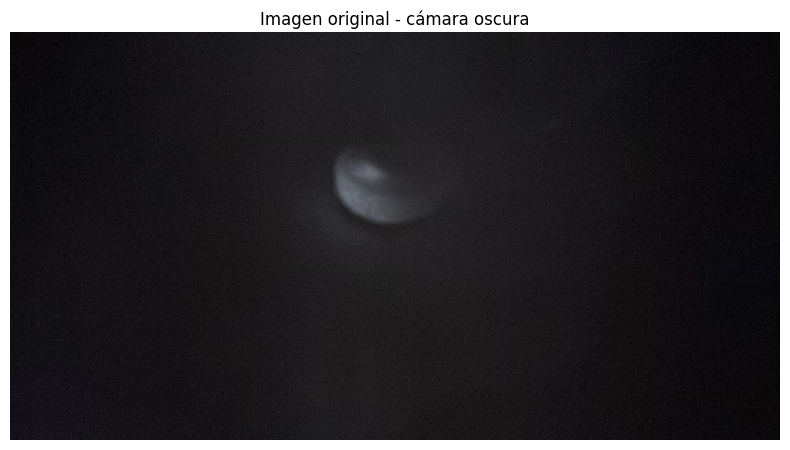

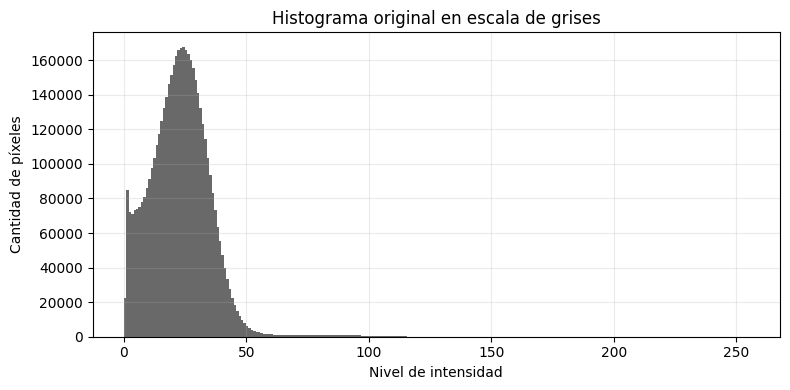

In [25]:
# --- Actividad 1: rutas y utilidades ---

nombre_imagen_camara = "img_camara_oscura.jpg"
ruta_camara = carpeta_imagenes_tfi / nombre_imagen_camara
ruta_final_camara = carpeta_salidas_tfi / "img_camara_oscura_final.jpg"
ruta_comparacion_camara = carpeta_salidas_tfi / "img_camara_oscura_comparacion.jpg"
ruta_histogramas_camara = carpeta_salidas_tfi / "img_camara_oscura_histogramas.jpg"


def cargar_rgb(ruta):
    """Carga una imagen con OpenCV y la devuelve en RGB para visualizar con Matplotlib."""
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def guardar_rgb(ruta, imagen_rgb, calidad=95):
    """Guarda una imagen RGB en disco usando codificación BGR de OpenCV."""
    ruta.parent.mkdir(parents=True, exist_ok=True)
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(ruta), imagen_bgr, [cv2.IMWRITE_JPEG_QUALITY, calidad])


def mostrar_imagen(imagen, titulo="Imagen", cmap=None):
    plt.figure(figsize=(8, 5))
    plt.imshow(imagen, cmap=cmap)
    plt.title(titulo)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo="Histograma"):
    plt.figure(figsize=(8, 4))
    plt.hist(imagen_gris.ravel(), bins=256, range=(0, 255), color="dimgray")
    plt.title(titulo)
    plt.xlabel("Nivel de intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def calcular_metricas_gris(imagen_gris):
    """Calcula métricas simples para sostener el diagnóstico y la comparación."""
    hist = cv2.calcHist([imagen_gris], [0], None, [256], [0, 256]).ravel()
    prob = hist / max(hist.sum(), 1)
    prob = prob[prob > 0]

    p1, p5, p95, p99 = np.percentile(imagen_gris, [1, 5, 95, 99])
    mediana_filtrada = cv2.medianBlur(imagen_gris, 3)
    ruido_estimado = float(np.std(imagen_gris.astype(np.float32) - mediana_filtrada.astype(np.float32)))

    return {
        "brillo_medio": float(np.mean(imagen_gris)),
        "contraste_std": float(np.std(imagen_gris)),
        "p1": float(p1),
        "p5": float(p5),
        "p95": float(p95),
        "p99": float(p99),
        "rango_dinamico_p1_p99": float(p99 - p1),
        "nitidez_laplaciano": float(cv2.Laplacian(imagen_gris, cv2.CV_64F).var()),
        "entropia": float(-np.sum(prob * np.log2(prob))),
        "ruido_estimado": ruido_estimado,
        "banding_vertical_estimado": float(np.std(np.mean(imagen_gris, axis=0))),
    }


def imprimir_metricas(nombre, metricas):
    print(f"\n{nombre}")
    print("-" * len(nombre))
    for clave, valor in metricas.items():
        print(f"{clave:28s}: {valor:8.3f}")


if ruta_camara.exists():
    imagen_camara_rgb = cargar_rgb(ruta_camara)
    imagen_camara_gris = cv2.cvtColor(imagen_camara_rgb, cv2.COLOR_RGB2GRAY)
    print(f"Imagen cargada: {ruta_camara}")
    print(f"Dimensiones: {imagen_camara_rgb.shape[1]} x {imagen_camara_rgb.shape[0]} px")
    mostrar_imagen(imagen_camara_rgb, "Imagen original - cámara oscura")
    mostrar_histograma_gris(imagen_camara_gris, "Histograma original en escala de grises")
else:
    imagen_camara_rgb = None
    imagen_camara_gris = None
    print(f"ADVERTENCIA: no se encontró {ruta_camara}")
    print("Colocar allí la fotografía propia de cámara oscura para ejecutar el procesamiento completo.")

El histograma confirma que la imagen está subexpuesta (muy oscura) y posee bajo contraste. La mayoría de los píxeles se concentra en tonos oscuros y prácticamente no aparecen valores altos de intensidad. Esto indica que la imagen utiliza solo una pequeña parte del rango tonal disponible, provocando una apariencia apagada y poca separación entre el objeto central y el fondo. Además, el fondo oscuro domina gran parte de la distribución tonal.

## Diagnóstico cuantitativo

El histograma permite traducir observaciones visuales a términos medibles:

- Si la media y los percentiles altos quedan bajos, hay **subexposición**.
- Si la desviación estándar y el rango entre percentiles son reducidos, hay **bajo contraste**.
- Si el residuo respecto de una mediana local es alto, hay **ruido fino**.
- Si el promedio por columnas varía de forma sistemática, puede existir **banding vertical** o iluminación estructurada.

Estas métricas no reemplazan el criterio visual, pero ayudan a justificar por qué se elige una mejora local y suave.

In [26]:
if imagen_camara_gris is not None:
    metricas_original = calcular_metricas_gris(imagen_camara_gris)
    imprimir_metricas("Métricas de diagnóstico - original", metricas_original)

    diagnostico_textual = []
    if metricas_original["brillo_medio"] < 90:
        diagnostico_textual.append("subexposición / imagen oscura")
    if metricas_original["contraste_std"] < 45:
        diagnostico_textual.append("bajo contraste global")
    if metricas_original["ruido_estimado"] > 4:
        diagnostico_textual.append("ruido fino visible o probable")
    if metricas_original["nitidez_laplaciano"] < 80:
        diagnostico_textual.append("baja nitidez aparente / desenfoque")

    print("\nDiagnóstico automático orientativo:")
    print(", ".join(diagnostico_textual) if diagnostico_textual else "Sin degradación fuerte según umbrales simples.")
else:
    print("Diagnóstico cuantitativo pendiente: falta la imagen de entrada.")


Métricas de diagnóstico - original
----------------------------------
brillo_medio                :   22.681
contraste_std               :   12.531
p1                          :    1.000
p5                          :    3.000
p95                         :   41.000
p99                         :   58.000
rango_dinamico_p1_p99       :   57.000
nitidez_laplaciano          :  649.068
entropia                    :    5.535
ruido_estimado              :    6.199
banding_vertical_estimado   :    8.108

Diagnóstico automático orientativo:
subexposición / imagen oscura, bajo contraste global, ruido fino visible o probable


### Explicación breve de las métricas obtenidas:

Brillo medio (22.68):
- Indica que la imagen es muy oscura, ya que el promedio de intensidad está cerca del negro.

Contraste (12.53):
- El contraste es bajo, por eso los tonos de la imagen son muy parecidos y el objeto central se diferencia poco del fondo.

Percentiles (p1, p5, p95, p99):
- Muestran que casi toda la imagen se concentra en tonos oscuros y que incluso las zonas más iluminadas siguen siendo relativamente oscuras.

Rango dinámico (57):
- Confirma que la imagen utiliza una parte pequeña del rango tonal disponible, generando una apariencia apagada.

Nitidez Laplaciana (649):
- Intenta medir presencia de bordes y detalles, aunque puede verse afectada por el ruido. Visualmente la imagen sigue presentando desenfoque.

Entropía (5.53):
- Representa la cantidad de información visual. La imagen tiene información limitada debido a la oscuridad y la falta de detalle.

Ruido estimado (6.19):
- Confirma la presencia de granulado visible, especialmente en zonas oscuras.

Banding vertical (8.10):
- Sugiere la existencia de leves líneas o variaciones verticales en el fondo de la imagen.

## Recorte de región de interés

Primero se recorta la zona central de la imagen porque ahí aparece la proyección de la cámara oscura, que es la parte importante para analizar.

El fondo oscuro ocupa gran parte de la imagen y afecta el histograma y las métricas, ya que agrega muchos píxeles negros que no aportan información útil.

El recorte permite:

1. enfocar el análisis en la zona importante
2. reducir la influencia del fondo oscuro
3. mejorar el procesamiento posterior de contraste y reducción de ruido.

El recorte se realiza automáticamente detectando las zonas más iluminadas de la imagen. Si esa detección falla, el sistema utiliza un recorte central más conservador.

ROI seleccionada (x0, y0, x1, y1): (0, 0, np.int32(2599), 1601)


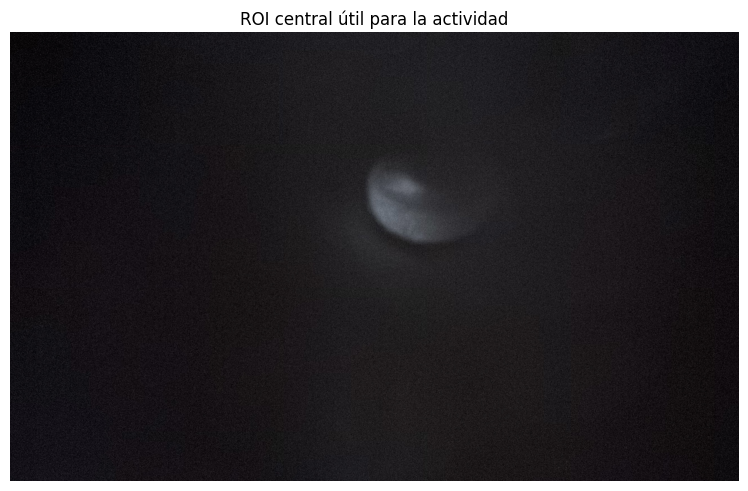

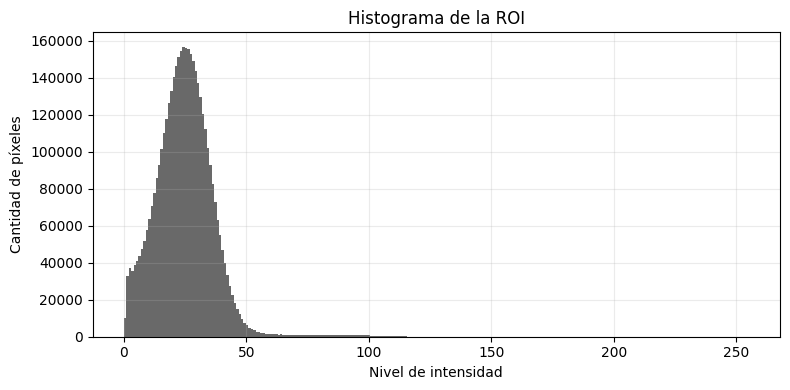

In [27]:
def recortar_roi_camara(imagen_rgb, margen=35, percentil=88):
    """Recorta automáticamente la zona informativa; si no hay señal clara, usa recorte central."""
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    alto, ancho = gris.shape

    umbral = np.percentile(gris, percentil)
    mascara = (gris >= umbral).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=2)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara, connectivity=8)
    if num_labels <= 1:
        usar_recorte_central = True
    else:
        areas = stats[1:, cv2.CC_STAT_AREA]
        idx = int(np.argmax(areas)) + 1
        area_relativa = stats[idx, cv2.CC_STAT_AREA] / float(alto * ancho)
        usar_recorte_central = area_relativa < 0.005

    if usar_recorte_central:
        x0, x1 = int(ancho * 0.15), int(ancho * 0.85)
        y0, y1 = int(alto * 0.15), int(alto * 0.85)
    else:
        x, y, w, h, _ = stats[idx]
        x0 = max(0, x - margen)
        y0 = max(0, y - margen)
        x1 = min(ancho, x + w + margen)
        y1 = min(alto, y + h + margen)

        # Evita recortes demasiado cerrados que podrían perder contexto de la proyección.
        min_w, min_h = int(ancho * 0.35), int(alto * 0.35)
        if (x1 - x0) < min_w:
            cx = (x0 + x1) // 2
            x0 = max(0, cx - min_w // 2)
            x1 = min(ancho, x0 + min_w)
        if (y1 - y0) < min_h:
            cy = (y0 + y1) // 2
            y0 = max(0, cy - min_h // 2)
            y1 = min(alto, y0 + min_h)

    roi = imagen_rgb[y0:y1, x0:x1]
    return roi, (x0, y0, x1, y1)


if imagen_camara_rgb is not None:
    imagen_roi_rgb, caja_roi = recortar_roi_camara(imagen_camara_rgb)
    imagen_roi_gris = cv2.cvtColor(imagen_roi_rgb, cv2.COLOR_RGB2GRAY)
    print(f"ROI seleccionada (x0, y0, x1, y1): {caja_roi}")
    mostrar_imagen(imagen_roi_rgb, "ROI central útil para la actividad")
    mostrar_histograma_gris(imagen_roi_gris, "Histograma de la ROI")
else:
    imagen_roi_rgb = None
    imagen_roi_gris = None
    caja_roi = None
    print("Recorte ROI pendiente: falta la imagen de entrada.")

## Estrategias comparadas

### Estrategia A 

**ROI → escala de grises → CLAHE suave → mediana 3×3 → ajuste leve de brillo/contraste**

Parámetros principales:

- `clipLimit = 1.5` Se usa un valor bajo para mejorar el contraste de forma suave y evitar exagerar el ruido.
- `tileGridSize = (8, 8)` Divide la imagen en regiones medianas para mejorar contraste local sin generar cambios artificiales.
- `medianBlur = 3` Se aplica una mediana pequeña para reducir granulado sin perder demasiado detalle.
- `alpha = 1.2`, `beta = 10` Se utilizan ajustes leves de contraste y brillo para aclarar la imagen sin “quemar” las zonas iluminadas.

Se elige como candidata principal porque mejora la visibilidad y el contraste de la proyección central sin modificar agresivamente la imagen original. La mediana posterior ayuda a reducir el ruido resaltado por CLAHE.

El objetivo general es recuperar legibilidad y contraste manteniendo una apariencia natural y evitando amplificar el ruido o crear detalles falsos.

### Estrategia B 

**ROI → escala de grises → equalizeHist global → Gaussian blur → sharpening suave**

Parámetros principales:

**equalizeHist global**
Se usa para aumentar el contraste de toda la imagen de manera rápida y fuerte.

**Gaussian blur (3x3)**
Se aplica un suavizado leve para reducir parte del ruido generado por la ecualización.

**sharpening suave**
Se intenta recuperar algo de definición y resaltar bordes después del suavizado.

Esta estrategia se utiliza como comparación porque permite observar los problemas de una mejora demasiado agresiva. Aunque aumenta mucho el contraste y hace más visible la proyección central, también exagera el ruido, el granulado y las bandas verticales del fondo.

Además, algunas zonas iluminadas quedan sobreexpuestas y aparecen bordes artificiales, haciendo que la imagen pierda naturalidad.

## Funciones para implementar estrategias

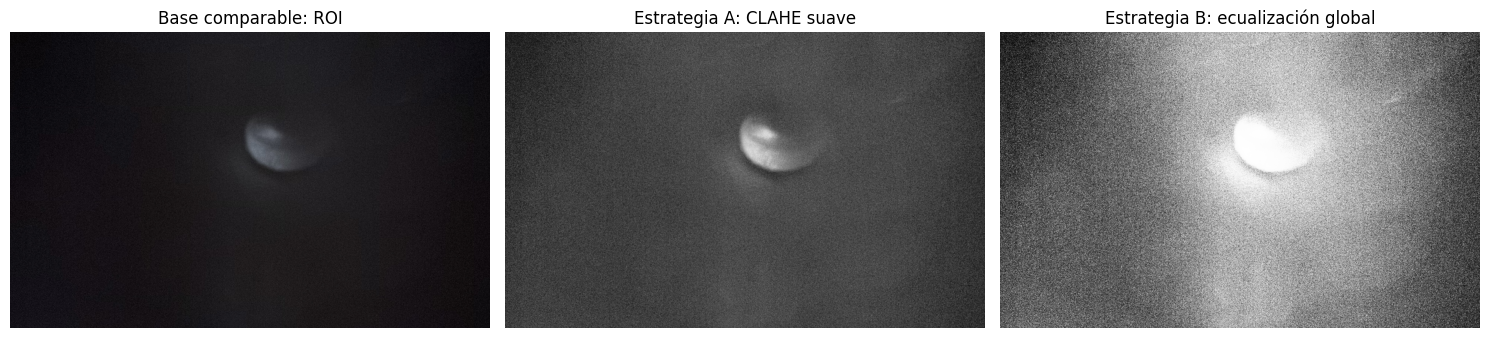

In [28]:
def estrategia_a_clahe_suave(imagen_roi_rgb, clip_limit=1.5, tile_grid=(8, 8), alpha=1.2, beta=10):
    gris = cv2.cvtColor(imagen_roi_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    mejorada = clahe.apply(gris)
    mejorada = cv2.medianBlur(mejorada, 3)
    mejorada = cv2.convertScaleAbs(mejorada, alpha=alpha, beta=beta)
    return cv2.cvtColor(mejorada, cv2.COLOR_GRAY2RGB)


def estrategia_b_ecualizacion_global(imagen_roi_rgb):
    gris = cv2.cvtColor(imagen_roi_rgb, cv2.COLOR_RGB2GRAY)
    ecualizada = cv2.equalizeHist(gris)
    suavizada = cv2.GaussianBlur(ecualizada, (3, 3), 0)
    desenfocada = cv2.GaussianBlur(suavizada, (0, 0), 1.0)
    sharpen_suave = cv2.addWeighted(suavizada, 1.25, desenfocada, -0.25, 0)
    return cv2.cvtColor(sharpen_suave, cv2.COLOR_GRAY2RGB)


if imagen_roi_rgb is not None:
    imagen_estrategia_a = estrategia_a_clahe_suave(imagen_roi_rgb)
    imagen_estrategia_b = estrategia_b_ecualizacion_global(imagen_roi_rgb)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(imagen_roi_rgb)
    ax[0].set_title("Base comparable: ROI")
    ax[1].imshow(imagen_estrategia_a)
    ax[1].set_title("Estrategia A: CLAHE suave")
    ax[2].imshow(imagen_estrategia_b)
    ax[2].set_title("Estrategia B: ecualización global")
    for eje in ax:
        eje.axis("off")
    plt.tight_layout()
    plt.show()
else:
    imagen_estrategia_a = None
    imagen_estrategia_b = None
    print("Comparación de estrategias pendiente: falta la imagen de entrada.")

## Comparación objetiva y elección final

La comparación no se basa únicamente en cuál “se ve mejor”, sino también en cómo cambian las métricas sobre la misma región de interés (ROI).

**Qué muestran las métricas:**
- La imagen original tiene brillo y contraste bajos, lo que confirma que la proyección está oscura y poco definida.
- La Estrategia A aumenta el brillo y el contraste de manera moderada, haciendo más visible la proyección central sin exagerar demasiado el ruido.
- La Estrategia B aumenta todavía más el contraste, pero también hace mucho más visibles el granulado, las bandas verticales y las zonas sobreexpuestas.

**La Estrategia A logra una mejora más equilibrada:**

- La proyección central se distingue mejor
- Aumenta la legibilidad
- Mantiene una apariencia relativamente natural
- Controla mejor el ruido.

**En cambio, la Estrategia B genera una mejora demasiado agresiva:**

- El fondo se vuelve muy ruidoso,
- Aparecen halos y zonas “quemadas”,
- La imagen pierde naturalidad.


**Elección final:**

- Se selecciona la Estrategia A (CLAHE suave) como resultado final porque mejora la visibilidad y el contraste sin convertir el ruido y los artefactos en el elemento dominante de la imagen.

In [29]:
if imagen_roi_gris is not None:
    gris_a = cv2.cvtColor(imagen_estrategia_a, cv2.COLOR_RGB2GRAY)
    gris_b = cv2.cvtColor(imagen_estrategia_b, cv2.COLOR_RGB2GRAY)

    metricas_roi = calcular_metricas_gris(imagen_roi_gris)
    metricas_a = calcular_metricas_gris(gris_a)
    metricas_b = calcular_metricas_gris(gris_b)

    imprimir_metricas("Base comparable - ROI", metricas_roi)
    imprimir_metricas("Estrategia A - CLAHE suave", metricas_a)
    imprimir_metricas("Estrategia B - ecualización global", metricas_b)

    print("\nLectura técnica:")
    print("- La estrategia A busca mejora moderada de contraste local y control de ruido.")
    print("- La estrategia B puede aumentar más el contraste numérico, pero tiende a exagerar ruido y halos.")
    print("- Por coherencia con el diagnóstico, se selecciona la Estrategia A como resultado final.")
else:
    metricas_roi = None
    metricas_a = None
    metricas_b = None
    print("Comparación objetiva pendiente: falta la imagen de entrada.")


Base comparable - ROI
---------------------
brillo_medio                :   24.521
contraste_std               :   12.155
p1                          :    1.000
p5                          :    6.000
p95                         :   42.000
p99                         :   63.000
rango_dinamico_p1_p99       :   62.000
nitidez_laplaciano          :  647.840
entropia                    :    5.498
ruido_estimado              :    6.185
banding_vertical_estimado   :    7.216

Estrategia A - CLAHE suave
--------------------------
brillo_medio                :   67.962
contraste_std               :   18.969
p1                          :   27.000
p5                          :   39.000
p95                         :   93.000
p99                         :  129.000
rango_dinamico_p1_p99       :  102.000
nitidez_laplaciano          :  494.058
entropia                    :    5.827
ruido_estimado              :    5.470
banding_vertical_estimado   :    9.945

Estrategia B - ecualización global
------

## Conclusión final y guardado


Se guarda como resultado final la Estrategia A porque logra una mejora más equilibrada de la imagen. La proyección central se vuelve más visible y con mejor contraste, pero sin exagerar el ruido ni generar demasiados artefactos artificiales.

**Problemas que mejora:**
- La imagen se ve menos oscura
- Mejora el contraste de la proyección central
- Aumenta la legibilidad de la zona importante
- Mantiene el ruido en niveles aceptables mientras mejora la visibilidad de la proyección central

**Problemas que no resuelve completamente:**
- La imagen sigue teniendo desenfoque;
- No se pueden recuperar detalles que nunca fueron capturados;
- Todavía se observan leves bandas verticales en el fondo;
- La poca iluminación original limita la calidad final.


La imagen obtenida mediante cámara oscura presenta principalmente problemas de oscuridad, poco contraste y desenfoque. Además, existe ruido visible debido a las condiciones de baja iluminación.

Por este motivo, el procesamiento final busca mejorar la visibilidad y el contraste de forma moderada, sin intentar “inventar” detalles que no existen realmente en la captura original.

**Elección final:**

Se selecciona la Estrategia A:

ROI → escala de grises → CLAHE suave → mediana 3×3 → ajuste leve de brillo/contraste

**Justificación:**
- El recorte ROI permite trabajar solo sobre la zona importante.
- CLAHE mejora el contraste local sin modificar agresivamente toda la imagen.
- La mediana ayuda a reducir ruido fino.
- El ajuste de brillo y contraste es suave para mantener una apariencia natural.
- La estrategia con ecualización global fue útil como comparación, pero aumentó demasiado el ruido y las bandas del fondo.
- Límites reconocidos

El desenfoque óptico no puede corregirse completamente mediante posprocesamiento. Si la captura original no tiene suficiente detalle, ningún filtro puede reconstruirlo de manera realista.

**La mejora más importante debería realizarse directamente en la captura:**

- Mejor iluminación,
- Mayor estabilidad,
- ISO más bajo,
- Exposición más controlada,
- Un orificio mejor ajustado para la cámara oscura.

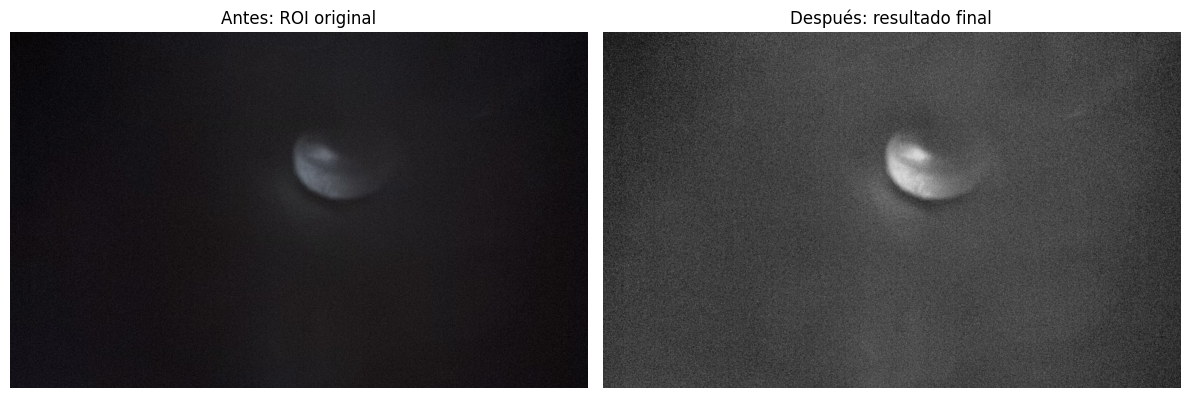

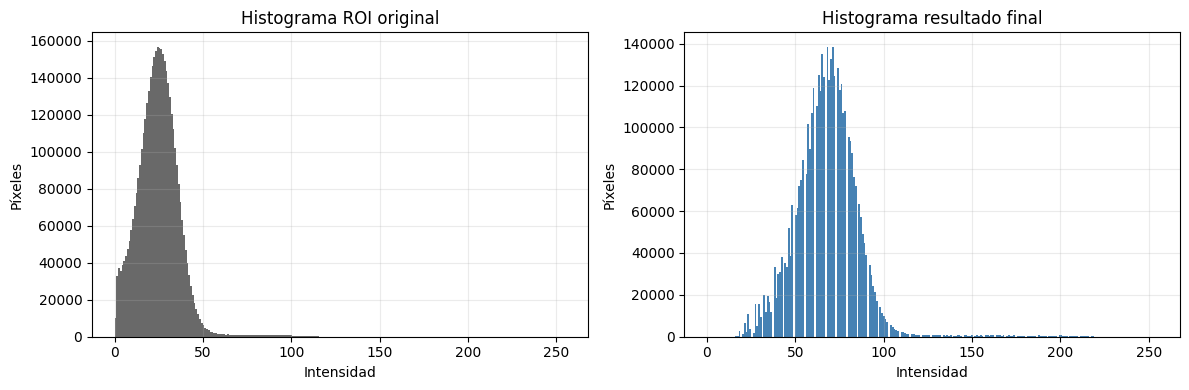

Imagen final guardada en: img_output_tfi1\img_camara_oscura_final.jpg
Comparación antes/después guardada en: img_output_tfi1\img_camara_oscura_comparacion.jpg
Histogramas guardados en: img_output_tfi1\img_camara_oscura_histogramas.jpg


In [30]:
if imagen_estrategia_a is not None:
    imagen_camara_final = imagen_estrategia_a
    guardar_rgb(ruta_final_camara, imagen_camara_final)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(imagen_roi_rgb)
    ax[0].set_title("Antes: ROI original")
    ax[1].imshow(imagen_camara_final)
    ax[1].set_title("Después: resultado final")
    for eje in ax:
        eje.axis("off")
    plt.tight_layout()
    plt.savefig(ruta_comparacion_camara, dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(imagen_roi_gris.ravel(), bins=256, range=(0, 255), color="dimgray")
    ax[0].set_title("Histograma ROI original")
    ax[0].set_xlabel("Intensidad")
    ax[0].set_ylabel("Píxeles")
    ax[1].hist(cv2.cvtColor(imagen_camara_final, cv2.COLOR_RGB2GRAY).ravel(), bins=256, range=(0, 255), color="steelblue")
    ax[1].set_title("Histograma resultado final")
    ax[1].set_xlabel("Intensidad")
    ax[1].set_ylabel("Píxeles")
    for eje in ax:
        eje.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(ruta_histogramas_camara, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Imagen final guardada en: {ruta_final_camara}")
    print(f"Comparación antes/después guardada en: {ruta_comparacion_camara}")
    print(f"Histogramas guardados en: {ruta_histogramas_camara}")
else:
    imagen_camara_final = None
    print("Guardado pendiente: falta la imagen de entrada.")

# Actividad 2: Imagen de medio grafico color

En esta imagen el principal problema está relacionado con el color y la iluminación.  
La tapa fue fotografiada con una luz cálida que genera una dominante amarillenta y hace que los colores originales pierdan intensidad.  
Además, se observa una leve pérdida de contraste y algunas rayaduras blancas sobre el fondo negro.

Para mejorar la imagen se compararán dos estrategias de corrección de color:

- Una estrategia en HSV, aumentando saturación y brillo para recuperar viveza visual.
- Una estrategia en LAB + CLAHE, separando luminosidad y color para corregir la dominante cálida y mejorar el contraste de forma más precisa.

Las rayaduras y marcas físicas no serán corregidas en esta actividad, ya que requieren técnicas de restauración localizada como inpainting.

## Funciones y carga de imagen

In [9]:
def cargar_rgb(ruta):
    """Abre una imagen color y la devuelve en formato RGB."""
    # Leemos la imagen con OpenCV en formato BGR.
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    # Verificamos que la lectura haya sido correcta.
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    # Convertimos de BGR a RGB para visualizar correctamente con Matplotlib.
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def cargar_gris(ruta):
    """Abre una imagen en escala de grises."""
    # Leemos la imagen directamente como grises.
    imagen_gris = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)

    # Verificamos que la lectura haya sido correcta.
    if imagen_gris is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    return imagen_gris


def mostrar_imagen(imagen, titulo="Imagen"):
    """Muestra una sola imagen con un titulo."""
    # Definimos el tamano general de la figura.
    plt.figure(figsize=(7, 6), constrained_layout=True)

    # Elegimos el mapa de color segun la cantidad de dimensiones.
    mapa_de_color = None
    if imagen.ndim == 2:
        mapa_de_color = "gray"

    # Dibujamos la imagen y su titulo.
    plt.imshow(imagen, cmap=mapa_de_color)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_comparacion(imagen_izquierda, imagen_derecha, titulo_izquierda, titulo_derecha):
    """Muestra una comparacion simple entre dos imagenes."""
    # Creamos una figura con dos ejes lado a lado.
    figura, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # Definimos el mapa de color para la imagen izquierda.
    mapa_izquierda = None
    if imagen_izquierda.ndim == 2:
        mapa_izquierda = "gray"

    # Dibujamos la imagen izquierda.
    ejes[0].imshow(imagen_izquierda, cmap=mapa_izquierda)
    ejes[0].set_title(titulo_izquierda, fontweight="bold", loc="left")
    ejes[0].axis("off")

    # Definimos el mapa de color para la imagen derecha.
    mapa_derecha = None
    if imagen_derecha.ndim == 2:
        mapa_derecha = "gray"

    # Dibujamos la imagen derecha.
    ejes[1].imshow(imagen_derecha, cmap=mapa_derecha)
    ejes[1].set_title(titulo_derecha, fontweight="bold", loc="left")
    ejes[1].axis("off")

    plt.show()


def mostrar_histograma_gris(imagen):
    """Muestra el histograma en grises de una imagen color o gris."""
    # Convertimos a grises si la imagen viene en color.
    imagen_gris = imagen
    if imagen.ndim == 3:
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    # Calculamos el histograma con NumPy.
    histograma, bordes = np.histogram(imagen_gris.flatten(), bins=256, range=[0, 256])

    # Dibujamos la curva del histograma.
    plt.figure(figsize=(10, 4), constrained_layout=True)
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title("Histograma en escala de grises", fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de pixeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_canales_rgb(imagen_rgb):
    """Muestra la imagen color y sus tres canales por separado."""
    # Extraemos los tres canales principales.
    canal_rojo = imagen_rgb[:, :, 0]
    canal_verde = imagen_rgb[:, :, 1]
    canal_azul = imagen_rgb[:, :, 2]

    # Creamos una figura de cuatro paneles.
    figura, ejes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    # Mostramos la imagen original.
    ejes[0, 0].imshow(imagen_rgb)
    ejes[0, 0].set_title("Imagen original", fontweight="bold", loc="left")
    ejes[0, 0].axis("off")

    # Mostramos el canal rojo.
    ejes[0, 1].imshow(canal_rojo, cmap="gray")
    ejes[0, 1].set_title("Canal rojo", fontweight="bold", loc="left")
    ejes[0, 1].axis("off")

    # Mostramos el canal verde.
    ejes[1, 0].imshow(canal_verde, cmap="gray")
    ejes[1, 0].set_title("Canal verde", fontweight="bold", loc="left")
    ejes[1, 0].axis("off")

    # Mostramos el canal azul.
    ejes[1, 1].imshow(canal_azul, cmap="gray")
    ejes[1, 1].set_title("Canal azul", fontweight="bold", loc="left")
    ejes[1, 1].axis("off")

    plt.show()


def guardar_rgb(ruta_salida, imagen_rgb):
    """Guarda una imagen RGB en disco."""
    # Convertimos la imagen a BGR para que OpenCV la guarde correctamente.
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Guardamos la imagen en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_bgr)


def guardar_gris(ruta_salida, imagen_gris):
    """Guarda una imagen en escala de grises."""
    # Guardamos la imagen directamente en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_gris)


Working dir: c:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB
Ruta usada: c:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB\005 - TFI_1\img_input_tfi1\img-medio-grafico-color.jpg
Existe: False
Buscando archivo en el proyecto...
Encontrado en: c:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB\img_input_tfi1\img-medio-grafico-color.jpg


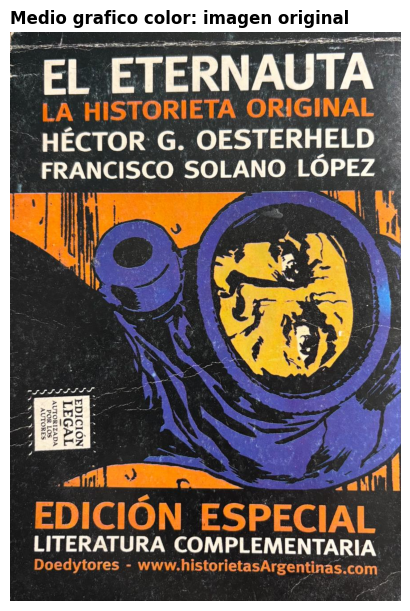

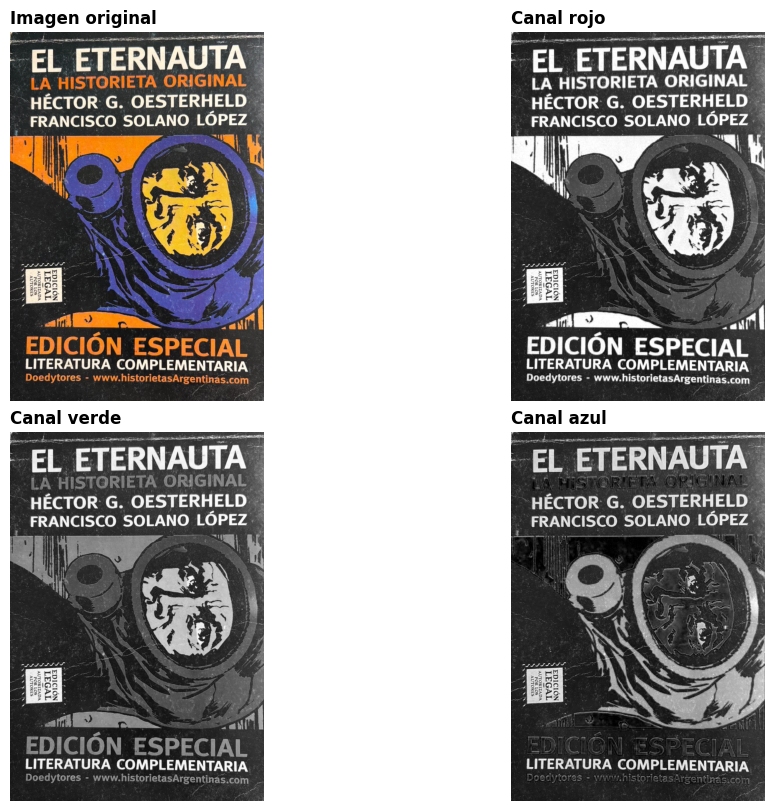

In [10]:
plt.rcParams['figure.figsize'] = (8, 5)

# =========================
# CONFIG
# =========================
nombre_imagen_medio_color = "img-medio-grafico-color.jpg"

# =========================
# DEBUG (opcional pero útil)
# =========================
print("Working dir:", os.getcwd())

# =========================
# CARGA SEGURA
# =========================
imagen_medio_color_rgb = None

if nombre_imagen_medio_color != "":
    base = Path.cwd()

    # Ruta esperada
    ruta_medio_color = base / "005 - TFI_1" / "img_input_tfi1" / nombre_imagen_medio_color

    print("Ruta usada:", ruta_medio_color)
    print("Existe:", ruta_medio_color.exists())

    # Si no existe, buscar automáticamente en todo el proyecto
    if not ruta_medio_color.exists():
        print("Buscando archivo en el proyecto...")
        encontrados = list(base.rglob(nombre_imagen_medio_color))
        
        if len(encontrados) > 0:
            ruta_medio_color = encontrados[0]
            print("Encontrado en:", ruta_medio_color)
        else:
            raise FileNotFoundError(f"No se encontró {nombre_imagen_medio_color} en el proyecto")

    # Cargar imagen
    imagen_medio_color_rgb = cargar_rgb(ruta_medio_color)

    # Mostrar (asegurate de haber ejecutado las funciones antes)
    mostrar_imagen(imagen_medio_color_rgb, "Medio grafico color: imagen original")
    mostrar_canales_rgb(imagen_medio_color_rgb)



## Diagnostico inicial

**Diagnóstico inicial:**  
- La imagen corresponde a la tapa de un libro fotografiada con iluminación ambiente cálida.  
- Se observa una dominante amarillenta que modifica los colores originales de impresión.  
- El naranja pierde intensidad y el azul/violeta aparece menos saturado de lo esperado.  
- También se detectan rayaduras blancas sobre el fondo negro y una leve pérdida de contraste general causada por la iluminación indirecta.

**Objetivo de mejora:**  
- Recuperar el balance de color y la viveza de la tapa.  
- Reducir la dominante cálida para acercar el naranja y el azul a sus tonos originales de impresión.  
- Mejorar ligeramente el contraste sin alterar demasiado la apariencia natural del material.

## Estrategias y conclusiones

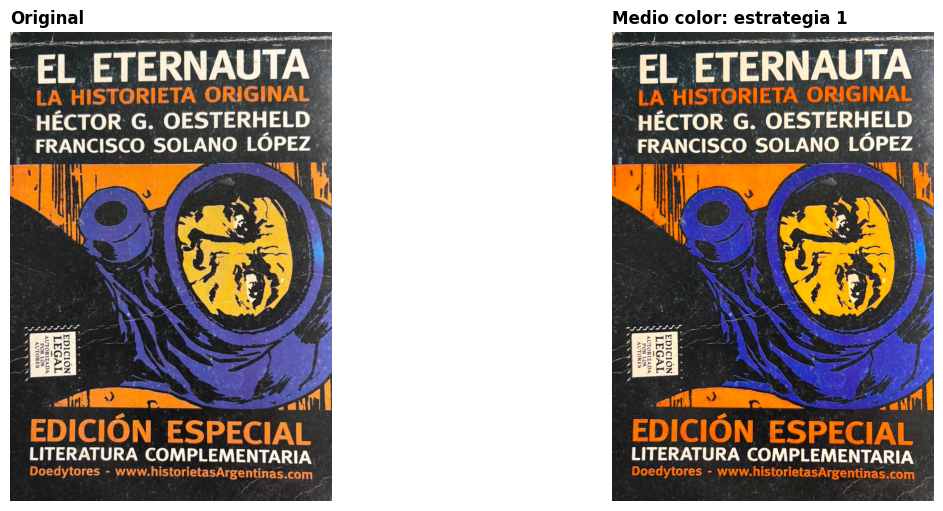

In [11]:
imagen_medio_color_estrategia_1 = None

if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_1 = imagen_medio_color_rgb.copy()

    # Convertimos a HSV para manipular saturación e intensidad por separado.
    # En HSV el canal S controla la viveza del color sin afectar el tono (H).
    hsv = cv2.cvtColor(imagen_medio_color_estrategia_1, cv2.COLOR_RGB2HSV).astype("float32")

    # Subimos la saturación un 40%. Si el valor supera 255 lo recortamos.
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.4, 0, 255)

    # También subimos levemente el brillo para compensar la luz ambiente oscura.
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * 1.1, 0, 255)

    imagen_medio_color_estrategia_1 = cv2.cvtColor(
        hsv.astype("uint8"), cv2.COLOR_HSV2RGB
    )

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_1,
        "Original",
        "Medio color: estrategia 1"
    )


**Resultado:**
- La mejora en HSV incrementa la saturación de todos los colores por igual.
- El naranja y el azul ganan viveza, pero la dominante cálida no se corrige: 
- Como el tono (H) no se toca, el sesgo amarillento de la iluminación se mantiene. 
- El resultado es más vistoso pero no más fiel al color original de impresión.


**Lo positivo:**
- Mejora visual inmediata
- Hace que naranja y azul resalten más
- Mantiene bien los tonos originales

**Problema principal:**
- HSV NO corrige dominantes de color.
- El canal Hue (H) se mantiene prácticamente intacto.
- Si la iluminación agregó amarillo, la imagen sigue teniendo ese sesgo, solamente más saturado. Eso produce una imagen “más vistosa”, pero no más fiel.

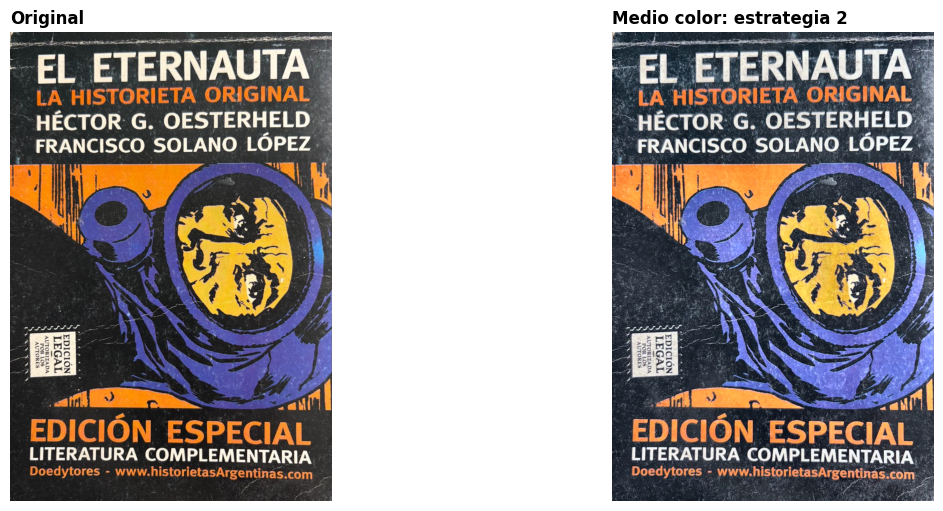

In [12]:
imagen_medio_color_estrategia_2 = None

if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_2 = imagen_medio_color_rgb.copy()

    # Convertimos a LAB. En este espacio:
    # L = luminosidad, A = eje verde-rojo, B = eje azul-amarillo.
    # La dominante cálida se manifiesta como exceso en el canal B (más amarillo).
    lab = cv2.cvtColor(imagen_medio_color_estrategia_2, cv2.COLOR_RGB2LAB).astype("float32")

    # Aplicamos CLAHE sobre L para mejorar contraste sin saturar zonas ya claras.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0].astype("uint8"))

    # Corregimos la dominante restando del canal B (reducimos el exceso de amarillo).
    # El valor 8 fue elegido observando que la dominante es moderada, no extrema.
    lab[:, :, 2] = np.clip(lab[:, :, 2] - 8, 0, 255)

    imagen_medio_color_estrategia_2 = cv2.cvtColor(
        lab.astype("uint8"), cv2.COLOR_LAB2RGB
    )

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_2,
        "Original",
        "Medio color: estrategia 2"
    )


**Resultados:**
- La estrategia en LAB permite corregir el contraste y el color por separado.
- CLAHE mejora los detalles y el contraste de la imagen sin modificar los colores originales.
- La reducción del canal B disminuye el tono amarillento causado por la iluminación ambiente.
- Los colores principales de la tapa, especialmente el azul/violeta y el naranja, quedan más equilibrados visualmente.
- A diferencia de HSV, esta técnica no solo aumenta la intensidad de los colores, sino que también corrige el problema de coloración cálida de la imagen.

**Lo positivo:**
- El espacio de color LAB permite separar luminancia y crominancia, logrando una corrección más precisa.
- CLAHE mejora detalles locales y contraste sin sobreexponer la imagen.
- La imagen final mantiene una apariencia más natural y fiel al material original.
- La corrección del canal B compensa el exceso de amarillo sin alterar excesivamente otros colores.

**Problema principal:**
- Si la reducción del canal B es demasiado agresiva, puede aparecer una dominante azul artificial.
- CLAHE puede aumentar ligeramente el ruido o las marcas del desgaste físico presentes en la tapa.


**Se elige la estrategia 2 (LAB + CLAHE) porque resuelve mejor el problema principal de la imagen:**  
- La dominante amarillenta generada por la iluminación ambiente.  
- HSV aumenta la saturación y hace los colores más intensos, pero no corrige el problema de color de fondo.  
- En cambio, el espacio LAB permite trabajar por separado la luminosidad y el color.  
- CLAHE mejora el contraste y los detalles sin alterar los colores originales.  
- La corrección sobre el canal B reduce el exceso de amarillo y equilibra mejor los tonos de la tapa.  
- Como resultado, la imagen queda más natural y visualmente más cercana al material original.  

**Límite del método:**  
- Las rayaduras y marcas blancas del desgaste físico no se eliminan con estas técnicas.  
- Ese tipo de defectos requiere métodos de restauración localizada, como inpainting, que están fuera del alcance de una corrección global de color y contraste.

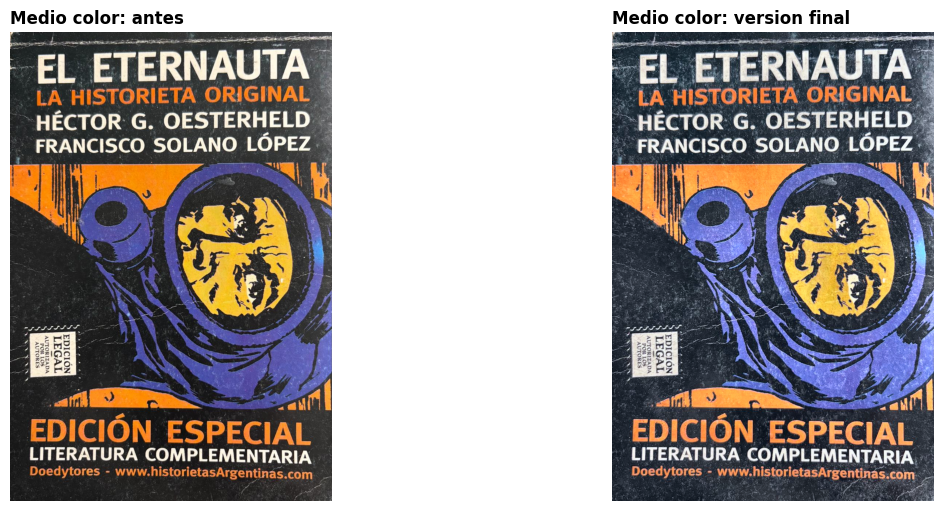

Salida guardada en: C:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB\img_output_tfi1\img_medio_grafico_color_final.png


In [22]:
# Elegimos la estrategia 2 como versión final.
imagen_medio_color_final = imagen_medio_color_estrategia_2

if imagen_medio_color_final is not None:
    ruta_salida_medio_color = carpeta_salidas_tfi / "img_medio_grafico_color_final.png"
    guardar_rgb(ruta_salida_medio_color, imagen_medio_color_final)

    if imagen_medio_color_rgb is not None:
        mostrar_comparacion(
            imagen_medio_color_rgb,
            imagen_medio_color_final,
            "Medio color: antes",
            "Medio color: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_color.resolve()}")

# Actividad 3: Imagen de medio grafico blanco/negro

## Funciones y carga de imagen

Working dir : c:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB
Ruta usada  : img_input_tfi1\img-medio-grafico-blanco-negro.jpg
Existe      : True
Imagen cargada: 4078x2799 px


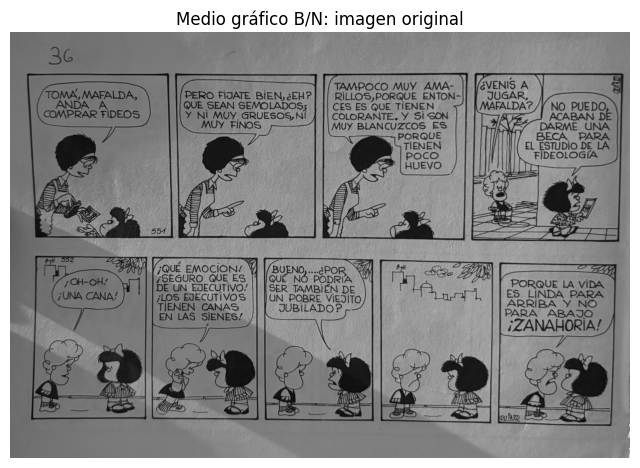

In [14]:

import matplotlib.pyplot as plt

def mostrar(imagen, titulo="", cmap=None, figsize=(8,8)):
    plt.figure(figsize=figsize)
    
    if len(imagen.shape) == 2:
        plt.imshow(imagen, cmap=cmap)
    else:
        plt.imshow(imagen)

    plt.title(titulo)
    plt.axis("off")
    plt.show()


# Carpetas 
carpeta_imagenes_tfi = Path("img_input_tfi1")
carpeta_salidas      = Path("img_output_tfi1")
carpeta_salidas.mkdir(parents=True, exist_ok=True)

# Nombre del archivo 
nombre_imagen_medio_bn = "img-medio-grafico-blanco-negro.jpg"

# Carga robusta 
imagen_medio_bn_gris = None
ruta_medio_bn = carpeta_imagenes_tfi / nombre_imagen_medio_bn

print(f"Working dir : {Path.cwd()}")
print(f"Ruta usada  : {ruta_medio_bn}")
print(f"Existe      : {ruta_medio_bn.exists()}")

if not ruta_medio_bn.exists():
    print("Buscando archivo en el proyecto...")
    resultados = list(Path(".").rglob(nombre_imagen_medio_bn))
    if resultados:
        ruta_medio_bn = resultados[0]
        print(f"Encontrada en: {ruta_medio_bn}")
    else:
        print(f"ERROR: No se encontró '{nombre_imagen_medio_bn}'.")
        if carpeta_imagenes_tfi.exists():
            print("Archivos disponibles en imagenes_tfi1:")
            for f in carpeta_imagenes_tfi.iterdir():
                print(f"  {f.name}")

if ruta_medio_bn.exists():
    imagen_medio_bn_gris = cv2.imread(str(ruta_medio_bn), cv2.IMREAD_GRAYSCALE)
    if imagen_medio_bn_gris is None:
        print("ERROR: OpenCV no pudo leer el archivo.")
    else:
        print(f"Imagen cargada: {imagen_medio_bn_gris.shape[1]}x{imagen_medio_bn_gris.shape[0]} px")
        mostrar(imagen_medio_bn_gris, "Medio gráfico B/N: imagen original", cmap="gray")



## Diagnostico inicial

**Diagnostico:**
- La imagen es una página de historieta (Mafalda) fotografiada con luz ambiente. 

Presenta iluminación marcadamente desigual:
 
- Hay una sombra pronunciada en sector inferior izquierdo que oscurece el fondo. 
- El papel tiene tono crema (no blanco puro) y el contenido mezcla texto en globos con trazos de dibujo y zonas negras densas. Un umbral global (Otsu) fallará en las zonas sombreadas porque el valor del fondo varía espacialmente.

**Objetivo:**
- Binarizar la página separando trazos y texto del fondo de manera uniforme 
- En toda la superficie, incluyendo la zona con sombra, sin generar puntos 
- Espurios ni perder globos de diálogo.



## Estrategias

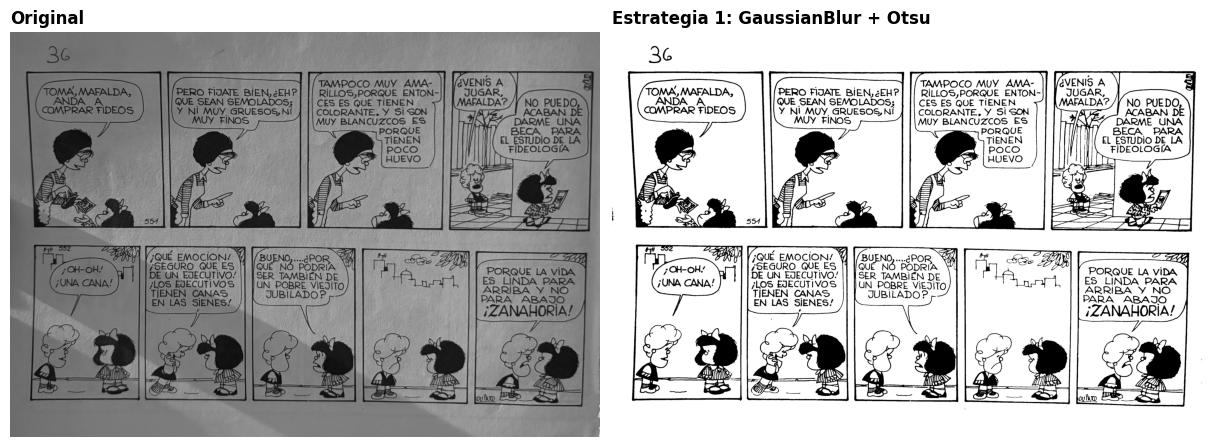

In [15]:
imagen_medio_bn_estrategia_1 = None

if imagen_medio_bn_gris is not None:

    suavizada_1 = cv2.GaussianBlur(imagen_medio_bn_gris, (5, 5), 0)

    _, imagen_medio_bn_estrategia_1 = cv2.threshold(
        suavizada_1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_1,
        "Original",
        "Estrategia 1: GaussianBlur + Otsu"
    )

**Observacion de estrategia 1:**

- Otsu calcula automáticamente el umbral óptimo aprovechando la distribución bimodal del histograma: un pico en los valores oscuros (tinta) y otro en los claros (papel crema).
- El resultado muestra blancos puros, negros limpios y globos de diálogo con texto perfectamente legible.
- La sombra del sector inferior izquierdo no invalida el umbral global porque la diferencia tonal entre tinta y papel se mantiene aun en esa zona.


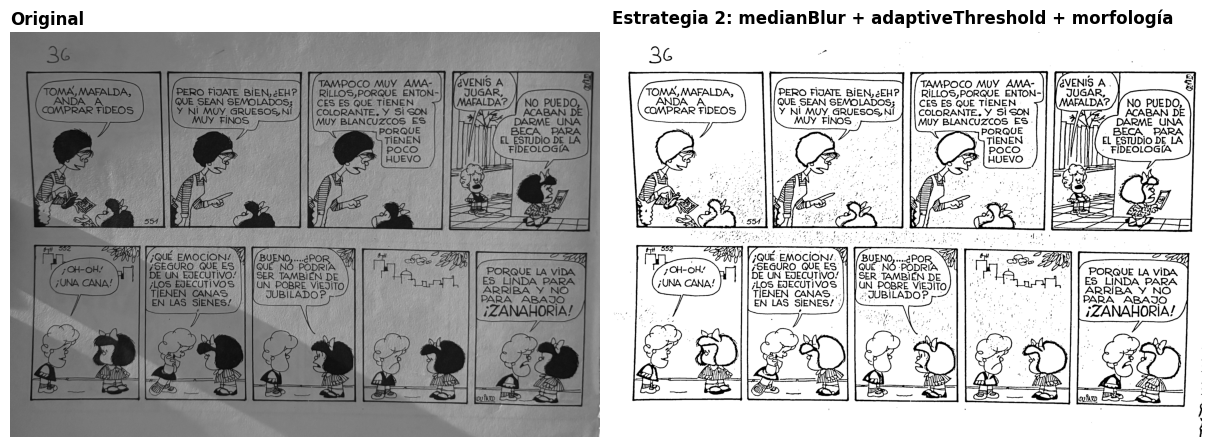

In [16]:
imagen_medio_bn_estrategia_2 = None

if imagen_medio_bn_gris is not None:

    # Mediana k=3: reduce ruido puntual preservando bordes de trazos y letras
    suavizada_2 = cv2.medianBlur(imagen_medio_bn_gris, 3)

    # adaptiveThreshold: calcula umbral distinto por región local.
    # blockSize=71: ventana grande para capturar la sombra gradual de escala amplia.
    # C=10: compensa el fondo crema del papel sin agresividad excesiva.
    imagen_medio_bn_estrategia_2 = cv2.adaptiveThreshold(
        suavizada_2,
        maxValue=255,
        adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        thresholdType=cv2.THRESH_BINARY,
        blockSize=71,
        C=10
    )

    # Apertura (2,2): elimina puntos blancos aislados residuales del papel
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    imagen_medio_bn_estrategia_2 = cv2.morphologyEx(
        imagen_medio_bn_estrategia_2, cv2.MORPH_OPEN, kernel
    )
    # Cierre (2,2): une pequeñas interrupciones en trazos finos del dibujo
    imagen_medio_bn_estrategia_2 = cv2.morphologyEx(
        imagen_medio_bn_estrategia_2, cv2.MORPH_CLOSE, kernel
    )

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_2,
        "Original",
        "Estrategia 2: medianBlur + adaptiveThreshold + morfología"
    )

**Observacion de estrategia 2:**

- El umbral adaptativo calcula un valor de corte distinto por región local. Si bien maneja variaciones de iluminación, en esta imagen introduce grano visible en las zonas de papel: el fondo no queda blanco puro sino con textura residual que ensucia la lectura. 
- La ventana de blockSize=71 intenta capturar la tendencia de iluminación pero reacciona también a la trama del papel crema, generando artefactos que degradan la calidad final.

In [23]:
imagen_medio_bn_final = imagen_medio_bn_estrategia_2

if imagen_medio_bn_final is not None:

    ruta_salida_medio_bn = (
        carpeta_salidas / "img_medio_grafico_final.png"
    )

    cv2.imwrite(
        str(ruta_salida_medio_bn),
        imagen_medio_bn_final
    )

    print(
        f"Salida guardada en: "
        f"{ruta_salida_medio_bn.resolve()}"
    )

else:
    print("No hay imagen final para guardar.")

Salida guardada en: C:\Programacion\repositorio-ingenieria-datos\ifts24\fortunesky-barrios-cristian-damian-pid-1c-2026\005_TFI1_CORREGIDO\003 - LAB\img_output_tfi1\img_medio_grafico_final.png


## Conclusión


**Elegimos la estrategia 1 como versión final.**

Se elige la estrategia 1 (GaussianBlur + Otsu):
- El diagnóstico inicial asumía que la sombra iba a invalidar el umbral global, pero la comparación visual de resultados demostró lo contrario: el histograma de la historieta es suficientemente bimodal para que Otsu funcione correctamente incluso en la zona sombreada. 
- El resultado tiene blancos más puros, negros más limpios y globos de diálogo con mayor legibilidad que la estrategia adaptativa, que introduce ruido de textura en el papel. 

**Límite del método:** 
- Las zonas negras densas de los personajes (pelo, ropa) pierden detalle interno al binarizar, ya que el umbral no distingue entre negro de trazo y negro de relleno sólido.
